### Libraries

In [1]:
import os
import numpy as np
import nibabel as nb
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import helpers
import copy
from brainspace.mesh.mesh_io import read_surface
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.plotting import plot_hemispheres
from scipy.interpolate import griddata
from scipy.stats import zscore
from scipy.optimize import curve_fit
from scipy import stats

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)
# Labels and boolean mask
mask_surf = mask_5k != 0

f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

In [3]:
AFD_par_5k = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average_SWM1mm_fsLR5k.npy")
AFD_perp_5k = np.load("/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average_SWM1mm_fsLR5k.npy")

## Load Geodesic distance connectome

In [4]:
# -------------------------------
# Parameters
# -------------------------------
num_bins = 20
dist_range = [0, 160]
base = "/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0"

subjects = [
    "PNC003", "PNC006", "PNC011", "PNC018", "PNC019",
    "PNC022", "PNC024", "PNC025", "PNC026", "PNC037", "PNC038"
]

sessions = [
    "03", "03", "03", "03", "03",
    "03", "a2", "a1", "a1", "a1", "a1"
]

numFiles = len(subjects)

# -------------------------------
# Containers
# -------------------------------
ind_fc_h_l = np.zeros((numFiles, num_bins))
ind_fc_ev_l = np.zeros((numFiles, num_bins))
ind_fc_h_r = np.zeros((numFiles, num_bins))
ind_fc_ev_r = np.zeros((numFiles, num_bins))

GD_group_l = None
GD_group_r = None
FC_group_l = None
FC_group_r = None

# -------------------------------
# Subject loop
# -------------------------------
for i, (sub, ses) in enumerate(zip(subjects, sessions)):

    print(f"Processing {sub}")

    cnt_fc = (
        f"{base}/sub-{sub}/ses-{ses}/func/desc-me_task-rest_bold/surf/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_desc-FC.shape.gii"
    )

    cnt_gd = (
        f"{base}/sub-{sub}/ses-{ses}/dist/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_GD.shape.gii"
    )

    FC = nb.load(cnt_fc).darrays[0].data
    GD = nb.load(cnt_gd).darrays[0].data

    # hemisphere split
    fc_left  = FC[:4842, :4842]
    fc_right = FC[4842:, 4842:]
    gd_left  = GD[:4842, :4842]
    gd_right = GD[4842:, 4842:]

    # midwall masking
    fc_left_masked  = fc_left[np.ix_(mask_5k[:4842] == 1, mask_5k[:4842] == 1)]
    fc_right_masked = fc_right[np.ix_(mask_5k[4842:] == 1, mask_5k[4842:] == 1)]
    gd_left_masked  = gd_left[np.ix_(mask_5k[:4842] == 1, mask_5k[:4842] == 1)]
    gd_right_masked = gd_right[np.ix_(mask_5k[4842:] == 1, mask_5k[4842:] == 1)]

    # ---------------------------
    # Group FC accumulation (Fisher z)
    # ---------------------------
    FC_z_l = np.arctanh(fc_left_masked)
    np.fill_diagonal(FC_z_l, 3)

    FC_z_r = np.arctanh(fc_right_masked)
    np.fill_diagonal(FC_z_r, 3)

    if i == 0:
        FC_group_l = FC_z_l.copy()
        FC_group_r = FC_z_r.copy()
    else:
        FC_group_l += FC_z_l
        FC_group_r += FC_z_r

    if i == 0:
        GD_group_l = gd_left_masked.copy()
        GD_group_r = gd_right_masked.copy()
    else:
        GD_group_l += gd_left_masked
        GD_group_r += gd_right_masked

    # ---------------------------
    # Empirical variogram
    # ---------------------------
    h_left, ev_left = helpers.emp_variogram_conn(
        fc_left_masked,
        gd_left_masked,
        num_bins,
        dist_range
    )

    h_right, ev_right = helpers.emp_variogram_conn(
        fc_right_masked,
        gd_right_masked,
        num_bins,
        dist_range
    )

    ind_fc_h_l[i, :] = h_left
    ind_fc_ev_l[i, :] = ev_left
    ind_fc_h_r[i, :] = h_right
    ind_fc_ev_r[i, :] = ev_right

# -------------------------------
# Final group FC (inverse Fisher)
# -------------------------------
FC_group_l /= numFiles
FC_group_l = np.tanh(FC_group_l)

FC_group_r /= numFiles
FC_group_r = np.tanh(FC_group_r)

GD_group_l /= numFiles
GD_group_r /= numFiles

# -------------------------------
# Optional: enforce 0 dissimilarity at 0 mm (for visualization)
# -------------------------------
ind_fc_ev_l[:, 0] = 0
ind_fc_ev_r[:, 0] = 0

# -------------------------------
# Group-average variograms
# -------------------------------
h_l = ind_fc_h_l.mean(axis=0)
h_r = ind_fc_h_r.mean(axis=0)

mu_l = ind_fc_ev_l.mean(axis=0)
mu_r = ind_fc_ev_r.mean(axis=0)

Processing PNC003


/tmp/ipykernel_629314/566897790.py:68: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_l = np.arctanh(fc_left_masked)
/tmp/ipykernel_629314/566897790.py:71: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_r = np.arctanh(fc_right_masked)


Processing PNC006
Processing PNC011
Processing PNC018
Processing PNC019
Processing PNC022
Processing PNC024
Processing PNC025
Processing PNC026
Processing PNC037
Processing PNC038


## Whole-brain variogram

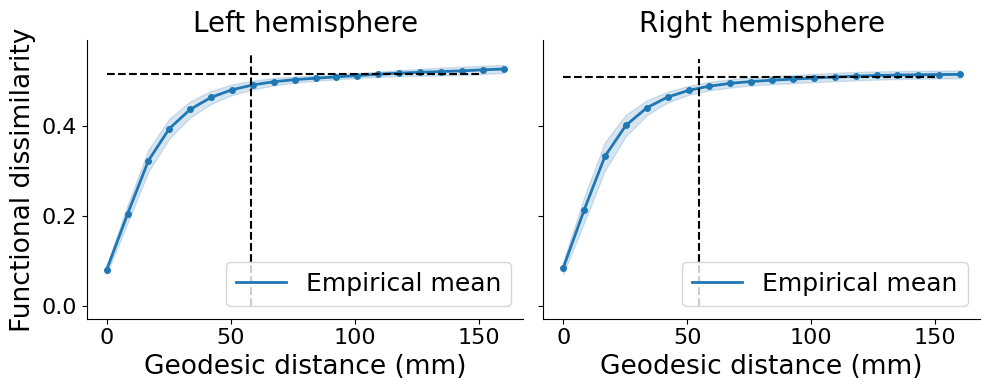

In [12]:
# -----------------------
# parameters
# -----------------------
smoothing = 0.9
alpha = 0.2
color = "#377eb8"
num_long = 100

# -----------------------
# Variogram models
# -----------------------
def exponential(h, r, c0, nugget):
    return nugget + c0 * (1 - np.exp(-h/(r/3)))

# -----------------------
# Fit variogram & calculate Sill/Range
# -----------------------
def fit_variogram(h, y, clipStart=1, clipEnd=18):
    x_clip = h[clipStart:clipEnd]
    y_clip = y[clipStart:clipEnd]
    x_long = np.linspace(0, 160, num_long)
    
    cof, _ = curve_fit(exponential, x_clip, y_clip, 
                       p0=[np.max(x_clip), np.max(y_clip), np.min(y_clip)],
                       bounds=(0.0001, [np.inf, np.inf, np.inf]), 
                       maxfev=5000)
    
    y_pred = exponential(x_long, *cof)
    
    # Sill & Range
    sill = cof[2] + cof[1]             # nugget + c0
    target = cof[2] + 0.95*cof[1]      # 95% sill
    h_fine = np.linspace(0, 160, 1000)
    y_fine = exponential(h_fine, *cof)
    idx = np.argmax(y_fine >= target)
    range_ = h_fine[idx]
    
    return y_pred, cof, sill, range_

# -----------------------
# Left & Right hemisphere data
# -----------------------
mu_l = ind_fc_ev_l.mean(axis=0)
h_l  = ind_fc_h_l.mean(axis=0)
mu_r = ind_fc_ev_r.mean(axis=0)
h_r  = ind_fc_h_r.mean(axis=0)

ModelPred_l, ModelCof_l, Sill_l, Range_l = fit_variogram(h_l, mu_l)
ModelPred_r, ModelCof_r, Sill_r, Range_r = fit_variogram(h_r, mu_r)

# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for hemi, (x, mu, ModelPred, Sill, Range, ind_fc_ev, ax) in enumerate([
    (h_l, mu_l, ModelPred_l, Sill_l, Range_l, ind_fc_ev_l, axs[0]),
    (h_r, mu_r, ModelPred_r, Sill_r, Range_r, ind_fc_ev_r, axs[1])
]):
    # Subject SD
    sigma = ind_fc_ev.std(axis=0)
    
    # Smoothed empirical mean & SD
    mu_s = gaussian_filter1d(mu, sigma=smoothing)
    sigma_s = gaussian_filter1d(sigma, sigma=smoothing)
    
    # Plot shaded SD
    ax.fill_between(x, mu_s - sigma_s, mu_s + sigma_s, color=color, alpha=alpha)
    
    # Plot empirical mean
    ax.plot(x, mu_s, "o", markersize=4)
    ax.plot(x, mu_s, "-", linewidth=2, color='#1f77b4', label="Empirical mean")
    
    # Plot model fit
    #ax.plot(np.linspace(0,160,num_long), ModelPred, color='orange', linewidth=2, label="Exponential fit")
    
    # Plot sill & range
    ax.plot([0,150], [Sill]*2, '--', c='black')
    ax.plot([Range]*2, [0, max(mu_s + sigma_s)*1.05], '--', c='black')
    
    # Titles & labels
    ax.set_title("Left hemisphere" if hemi==0 else "Right hemisphere", fontsize=20)
    ax.set_xlabel("Geodesic distance (mm)", fontsize=19)
    ax.tick_params(axis='both', labelsize=16)

axs[0].set_ylabel("Functional dissimilarity", fontsize=19)

# -----------------------
# Legend 왼쪽 아래
# -----------------------
for ax in axs:
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # 중복 제거
    ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=18)  # 위치 지정
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Yeo 7 networks

In [6]:
from brainstat.datasets import fetch_yeo_networks_metadata
from brainstat.datasets import fetch_parcellation

yeo_networks = fetch_parcellation("fsaverage5", "yeo", 7)
network_names, yeo_colormap = fetch_yeo_networks_metadata(7)

In [17]:
left = yeo_networks[:len(yeo_networks)//2]
right = yeo_networks[len(yeo_networks)//2:]

In [18]:
imgL = nb.gifti.GiftiImage()
imgR = nb.gifti.GiftiImage()
img = nb.gifti.GiftiImage()

dataL = nb.gifti.GiftiDataArray(left.astype(np.int32))
dataR = nb.gifti.GiftiDataArray(right.astype(np.int32))
data = nb.gifti.GiftiDataArray(yeo_networks.astype(np.int32))

imgL.add_gifti_data_array(dataL)
imgR.add_gifti_data_array(dataR)
img.add_gifti_data_array(data)

In [19]:
nb.save(imgL, '/host/verges/tank/data/youngeun/parcellations/lh.Yeo2011_7Networks_fsaverage5.shape.gii')
nb.save(imgR, '/host/verges/tank/data/youngeun/parcellations/rh.Yeo2011_7Networks_fsaverage5.shape.gii')

In [7]:
fsLR_5k_L =  nb.load('/host/verges/tank/data/youngeun/parcellations/lh.Yeo2011_7Networks_fsLR5k.shape.gii').darrays[0].data
fsLR_5k_R =  nb.load('/host/verges/tank/data/youngeun/parcellations/rh.Yeo2011_7Networks_fsLR5k.shape.gii').darrays[0].data

In [8]:
round_fsLR_5k_L = np.round(fsLR_5k_L).astype(int)
round_fsLR_5k_R = np.round(fsLR_5k_R).astype(int)
fsLR_5k_yeo = np.concatenate((round_fsLR_5k_L, round_fsLR_5k_R), axis=0)

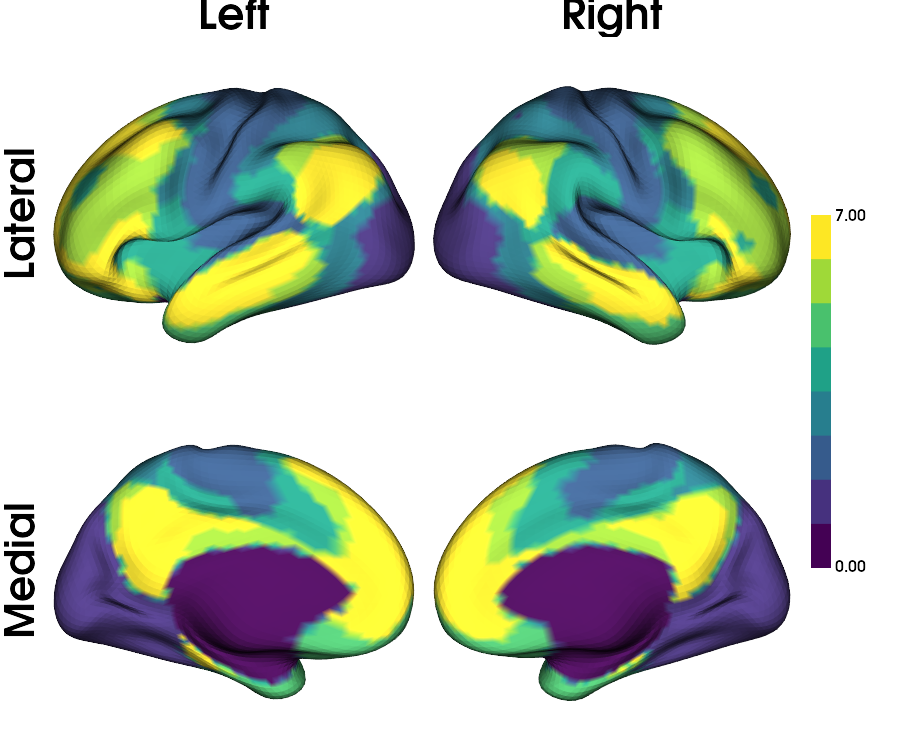

In [9]:
plot_hemispheres(inf_lh, inf_rh, array_name=fsLR_5k_yeo, cmap='viridis', nan_color=(0, 0, 0, 1),
                              zoom=1.3, size=(900, 750), embed_nb=True,
                              color_bar='right', layout_style='grid', 
                              label_text={'left': ['Lateral', 'Medial'], 'top': ['Left', 'Right']},
                              screenshot=False)

## Variogram by 7 yeo network

In [10]:
# -----------------------
# Network labels & colors
# -----------------------
net_names = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention",
    5: "Limbic",
    6: "Frontoparietal",
    7: "Default Mode"
}

net_colors = {
    1: (120/255, 18/255, 134/255),
    2: (70/255, 130/255, 180/255),
    3: (0/255, 118/255, 14/255),
    4: (196/255, 58/255, 250/255),
    5: (220/255, 248/255, 164/255),
    6: (230/255, 148/255, 34/255),
    7: (205/255, 62/255, 78/255),
}

In [15]:
num_bins = 20
dist_range = [0, 160]
n_sub = len(subjects)

#ind_fc_ev_net_l = {net: np.zeros((n_sub, num_bins)) for net in range(1,8)}
#ind_fc_ev_net_r = {net: np.zeros((n_sub, num_bins)) for net in range(1,8)}
ind_fc_ev_net_l = {net: np.full((n_sub, num_bins), np.nan) for net in range(1,8)}
ind_fc_ev_net_r = {net: np.full((n_sub, num_bins), np.nan) for net in range(1,8)}


GD_group_l = None
GD_group_r = None
FC_group_l = None
FC_group_r = None

In [16]:
for i, (sub, ses) in enumerate(zip(subjects, sessions)):

    print(f"Processing {sub}")

    cnt_fc = (
        f"{base}/sub-{sub}/ses-{ses}/func/desc-me_task-rest_bold/surf/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_desc-FC.shape.gii"
    )

    cnt_gd = (
        f"{base}/sub-{sub}/ses-{ses}/dist/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_GD.shape.gii"
    )
    
    FC = nb.load(cnt_fc).darrays[0].data
    GD = nb.load(cnt_gd).darrays[0].data

    fc_left  = FC[:4842, :4842]
    fc_right = FC[4842:, 4842:]
    gd_left  = GD[:4842, :4842]
    gd_right = GD[4842:, 4842:]

    mask_l = mask_5k[:4842] == 1
    mask_r = mask_5k[4842:] == 1

    fc_left_masked  = fc_left[np.ix_(mask_l, mask_l)]
    fc_right_masked = fc_right[np.ix_(mask_r, mask_r)]
    gd_left_masked  = gd_left[np.ix_(mask_l, mask_l)]
    gd_right_masked = gd_right[np.ix_(mask_r, mask_r)]

    yeo_l_masked = fsLR_5k_yeo[:4842][mask_l]
    yeo_r_masked = fsLR_5k_yeo[4842:][mask_r]

    FC_z_l = np.arctanh(fc_left_masked)
    FC_z_r = np.arctanh(fc_right_masked)
    np.fill_diagonal(FC_z_l, 3)
    np.fill_diagonal(FC_z_r, 3)
    
    if i == 0:
        FC_group_l = FC_z_l.copy()
        FC_group_r = FC_z_r.copy()
        GD_group_l = gd_left_masked.copy()
        GD_group_r = gd_right_masked.copy()
    else:
        FC_group_l += FC_z_l
        FC_group_r += FC_z_r
        GD_group_l += gd_left_masked
        GD_group_r += gd_right_masked

    for net in range(1, 8):

        net_idx_l = np.where(yeo_l_masked == net)[0]
        net_idx_r = np.where(yeo_r_masked == net)[0]
    
        if len(net_idx_l) > 30:
            fc_net_l = fc_left_masked[np.ix_(net_idx_l, net_idx_l)]
            gd_net_l = gd_left_masked[np.ix_(net_idx_l, net_idx_l)]
            _, ev_l = helpers.emp_variogram_conn(fc_net_l, gd_net_l, num_bins, dist_range)
            ind_fc_ev_net_l[net][i, :] = ev_l
    
        if len(net_idx_r) > 30:
            fc_net_r = fc_right_masked[np.ix_(net_idx_r, net_idx_r)]
            gd_net_r = gd_right_masked[np.ix_(net_idx_r, net_idx_r)]
            _, ev_r = helpers.emp_variogram_conn(fc_net_r, gd_net_r, num_bins, dist_range)
            ind_fc_ev_net_r[net][i, :] = ev_r

FC_group_l = np.tanh(FC_group_l / n_sub)
FC_group_r = np.tanh(FC_group_r / n_sub)
GD_group_l /= n_sub
GD_group_r /= n_sub

Processing PNC003


/tmp/ipykernel_2240890/3809255023.py:34: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_l = np.arctanh(fc_left_masked)
/tmp/ipykernel_2240890/3809255023.py:35: RuntimeWarning: divide by zero encountered in arctanh
  FC_z_r = np.arctanh(fc_right_masked)


Processing PNC006
Processing PNC011
Processing PNC018
Processing PNC019
Processing PNC022
Processing PNC024
Processing PNC025
Processing PNC026
Processing PNC037
Processing PNC038


In [17]:
smoothing = 0.9
net_results = []

for hemi_name, FC_group, GD_group, yeo_masked, ind_dict in [
    ("L", FC_group_l, GD_group_l, yeo_l_masked, ind_fc_ev_net_l),
    ("R", FC_group_r, GD_group_r, yeo_r_masked, ind_fc_ev_net_r)
]:

    for net in range(1, 8):

        net_idx = np.where(yeo_masked == net)[0]
        if len(net_idx) < 30:
            continue

        # -----------------------
        # GROUP mean curve (for plotting only)
        # -----------------------
        FC_net = FC_group[np.ix_(net_idx, net_idx)]
        GD_net = GD_group[np.ix_(net_idx, net_idx)]
        h, mu = helpers.emp_variogram_conn(
            FC_net, GD_net, num_bins, dist_range
        )

        mu_s = gaussian_filter1d(mu, sigma=smoothing)

        # -----------------------
        # INDIVIDUAL curves
        # -----------------------
        subj_ev = ind_dict[net]  # shape: (n_sub, num_bins)
        n_sub = subj_ev.shape[0]

        sill_ind = []
        range_ind = []

        for s in range(n_sub):

            y = subj_ev[s, :]
            y_s = gaussian_filter1d(y, sigma=smoothing)

            # ---- SILL ----
            sill_s = np.nanmean(y_s[-3:])
            sill_ind.append(sill_s)

            # ---- RANGE (95%) ----
            target = 0.95 * sill_s
            idx = np.where(y_s >= target)[0]

            if len(idx) > 0:
                range_ind.append(h[idx[0]])
            else:
                range_ind.append(np.nan)

        sill_ind = np.array(sill_ind)
        range_ind = np.array(range_ind)

        # -----------------------
        # GROUP mean of parameters
        # -----------------------
        sill_group  = np.nanmean(sill_ind)
        range_group = np.nanmean(range_ind)

        # SE for shading
        sigma = np.nanstd(subj_ev, axis=0)
        sigma_s = gaussian_filter1d(
            sigma / np.sqrt(n_sub) * 1.96,
            sigma=smoothing
        )

        net_results.append({
            "hemi": hemi_name,
            "net": net,
            "h": h,
            "mu_s": mu_s,               # group mean curve (for plot)
            "sigma_s": sigma_s,
            "sill": sill_group,         # averaged individual sill
            "range": range_group,       # averaged individual range
            "sill_ind": sill_ind,       # optional: keep for stats
            "range_ind": range_ind
        })

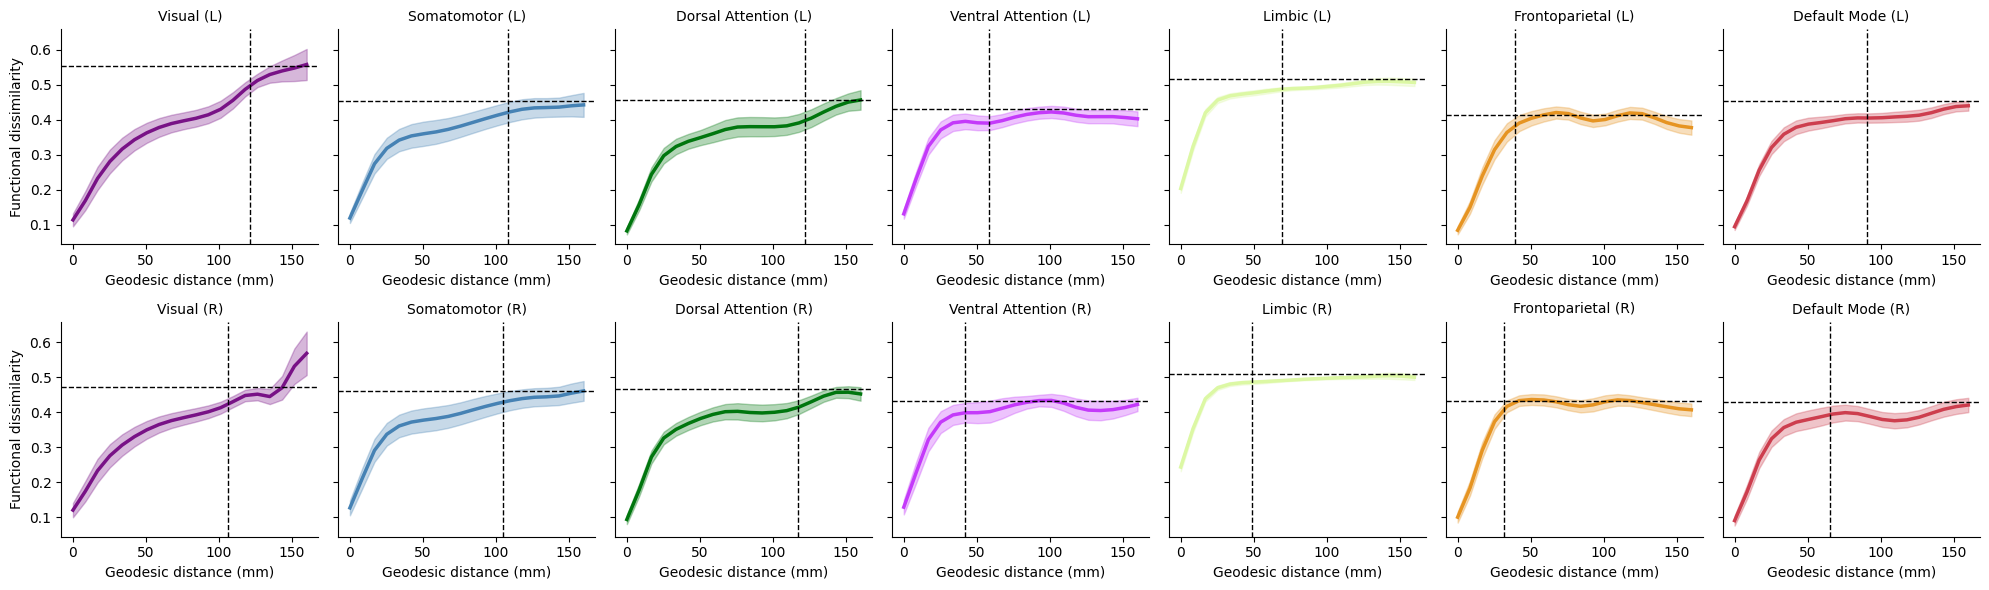

In [18]:
fig, axs = plt.subplots(2, 7, figsize=(20, 6), sharey=True)

for res in net_results:

    row = 0 if res["hemi"] == "L" else 1
    col = res["net"] - 1
    ax = axs[row, col]

    x = res["h"]
    mu_s = res["mu_s"]
    sigma_s = res["sigma_s"]
    color = net_colors[res["net"]]

    #ax.fill_between(x, mu_s - sigma_s, mu_s + sigma_s,
    #                color=color, alpha=0.25)

    ax.fill_between(x, mu_s - sigma_s, mu_s + sigma_s,
                color=color, alpha=0.3)
    
    ax.plot(x, mu_s, lw=2.5, color=color)

    ax.axhline(res["sill"], ls='--', c='k', lw=1)
    ax.axvline(res["range"], ls='--', c='k', lw=1)

    ax.set_title(f"{net_names[res['net']]} ({res['hemi']})", fontsize=10)
    ax.set_xlabel("Geodesic distance (mm)")
    if col == 0:
        ax.set_ylabel("Functional dissimilarity")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()